In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder,OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import precision_score,accuracy_score,recall_score,f1_score,confusion_matrix

In [2]:
df=pd.read_csv("loan_approval_data.csv")
df.sample(10)

,Applicant_ID,Applicant_Income,Coapplicant_Income,Employment_Status,Age,Marital_Status,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term,Loan_Purpose,Property_Area,Education_Level,Gender,Employer_Category,Loan_Approved
359,360.0,15245.0,3342.0,Contract,46.0,Married,3.0,641.0,1.0,0.54,17772.0,16498.0,NaN,48.0,Education,Rural,Graduate,Male,Government,No
909,910.0,19589.0,4225.0,Salaried,31.0,Single,3.0,752.0,0.0,0.37,1389.0,12314.0,25281.0,12.0,Home,Rural,Graduate,Female,Private,Yes
568,NaN,6809.0,269.0,Salaried,44.0,Married,1.0,587.0,4.0,0.20,14481.0,26490.0,29767.0,84.0,Personal,Urban,Not Graduate,Male,Business,No
99,100.0,2502.0,4090.0,Self-employed,27.0,Single,2.0,692.0,1.0,0.49,6391.0,39051.0,39299.0,60.0,Business,Semiurban,Graduate,NaN,MNC,No
245,246.0,9996.0,1380.0,Salaried,21.0,Married,1.0,681.0,2.0,0.26,17336.0,43747.0,32153.0,NaN,Home,Semiurban,Graduate,Female,Private,Yes
172,173.0,8546.0,4346.0,Self-employed,25.0,Single,NaN,600.0,0.0,0.43,12674.0,39284.0,31164.0,24.0,Car,Urban,Graduate,Female,Private,No
275,276.0,9455.0,NaN,Salaried,39.0,Married,2.0,754.0,1.0,0.28,19628.0,17110.0,11547.0,NaN,NaN,Rural,Graduate,Female,Private,Yes
693,694.0,6632.0,5592.0,Self-employed,31.0,Married,0.0,725.0,2.0,0.13,17700.0,44331.0,10481.0,48.0,Education,Urban,Graduate,Male,Private,Yes
720,721.0,7622.0,6542.0,Salaried,59.0,Single,0.0,601.0,2.0,0.44,6922.0,38311.0,27118.0,60.0,Education,Urban,NaN,Male,NaN,No
475,476.0,6312.0,3389.0,Self-employed,54.0,Married,2.0,551.0,3.0,0.28,9596.0,9643.0,NaN,72.0,Home,Rural,Graduate,Male,Business,No


In [3]:
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 20 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Applicant_ID        950 non-null    float64
 1   Applicant_Income    950 non-null    float64
 2   Coapplicant_Income  950 non-null    float64
 3   Employment_Status   950 non-null    object 
 4   Age                 950 non-null    float64
 5   Marital_Status      950 non-null    object 
 6   Dependents          950 non-null    float64
 7   Credit_Score        950 non-null    float64
 8   Existing_Loans      950 non-null    float64
 9   DTI_Ratio           950 non-null    float64
 10  Savings             950 non-null    float64
 11  Collateral_Value    950 non-null    float64
 12  Loan_Amount         950 non-null    float64
 13  Loan_Term           950 non-null    float64
 14  Loan_Purpose        950 non-null    object 
 15  Property_Area       950 non-null    object 
 16  Educati

Applicant_ID          50
Applicant_Income      50
Coapplicant_Income    50
Employment_Status     50
Age                   50
Marital_Status        50
Dependents            50
Credit_Score          50
Existing_Loans        50
DTI_Ratio             50
Savings               50
Collateral_Value      50
Loan_Amount           50
Loan_Term             50
Loan_Purpose          50
Property_Area         50
Education_Level       50
Gender                50
Employer_Category     50
Loan_Approved         50
dtype: int64

In [4]:
df=df.drop("Applicant_ID",axis=1)
df.head()

,Applicant_Income,Coapplicant_Income,Employment_Status,Age,Marital_Status,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term,Loan_Purpose,Property_Area,Education_Level,Gender,Employer_Category,Loan_Approved
0,17795.0,1387.0,Salaried,51.0,Married,0.0,637.0,4.0,0.53,19403.0,45638.0,16619.0,84.0,Personal,Urban,Not Graduate,Female,Private,No
1,2860.0,2679.0,Salaried,46.0,Married,3.0,621.0,2.0,0.30,2580.0,49272.0,38687.0,NaN,Car,Semiurban,Graduate,NaN,Private,No
2,7390.0,2106.0,Salaried,25.0,Single,2.0,674.0,4.0,0.20,13844.0,6908.0,27943.0,72.0,NaN,Urban,NaN,Female,Government,Yes
3,13964.0,8173.0,Salaried,40.0,Married,2.0,579.0,3.0,0.31,9553.0,10844.0,27819.0,60.0,Business,Rural,Graduate,Female,Government,No
4,13284.0,4223.0,Self-employed,31.0,Single,2.0,721.0,1.0,0.29,9386.0,37629.0,12741.0,72.0,Car,NaN,Graduate,Male,Private,Yes


# Filling Missing Values


In [5]:
#Filling Missing Values

numerical_col=df.select_dtypes(include=["float64"]).columns
categorical_col=df.select_dtypes(include=["object"]).columns
num_imp=SimpleImputer(strategy="mean")
df[numerical_col]=num_imp.fit_transform(df[numerical_col])
cat_imp=SimpleImputer(strategy="most_frequent")
df[categorical_col]=cat_imp.fit_transform(df[categorical_col])

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 19 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Applicant_Income    1000 non-null   float64
 1   Coapplicant_Income  1000 non-null   float64
 2   Employment_Status   1000 non-null   object 
 3   Age                 1000 non-null   float64
 4   Marital_Status      1000 non-null   object 
 5   Dependents          1000 non-null   float64
 6   Credit_Score        1000 non-null   float64
 7   Existing_Loans      1000 non-null   float64
 8   DTI_Ratio           1000 non-null   float64
 9   Savings             1000 non-null   float64
 10  Collateral_Value    1000 non-null   float64
 11  Loan_Amount         1000 non-null   float64
 12  Loan_Term           1000 non-null   float64
 13  Loan_Purpose        1000 non-null   object 
 14  Property_Area       1000 non-null   object 
 15  Education_Level     1000 non-null   object 
 16  Gender 

# EDA

In [7]:
df.head()

,Applicant_Income,Coapplicant_Income,Employment_Status,Age,Marital_Status,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term,Loan_Purpose,Property_Area,Education_Level,Gender,Employer_Category,Loan_Approved
0,17795.0,1387.0,Salaried,51.0,Married,0.0,637.0,4.0,0.53,19403.0,45638.0,16619.0,84.0,Personal,Urban,Not Graduate,Female,Private,No
1,2860.0,2679.0,Salaried,46.0,Married,3.0,621.0,2.0,0.30,2580.0,49272.0,38687.0,48.0,Car,Semiurban,Graduate,Male,Private,No
2,7390.0,2106.0,Salaried,25.0,Single,2.0,674.0,4.0,0.20,13844.0,6908.0,27943.0,72.0,Business,Urban,Graduate,Female,Government,Yes
3,13964.0,8173.0,Salaried,40.0,Married,2.0,579.0,3.0,0.31,9553.0,10844.0,27819.0,60.0,Business,Rural,Graduate,Female,Government,No
4,13284.0,4223.0,Self-employed,31.0,Single,2.0,721.0,1.0,0.29,9386.0,37629.0,12741.0,72.0,Car,Urban,Graduate,Male,Private,Yes


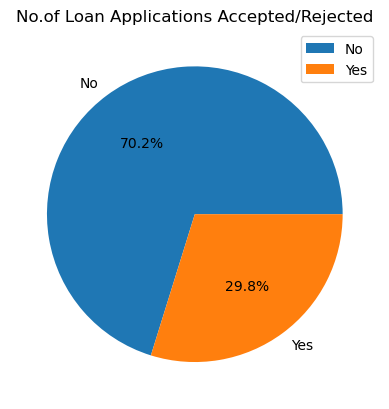

In [8]:
classes_count=df["Loan_Approved"].value_counts()
plt.pie(classes_count,labels=df["Loan_Approved"].unique(),autopct="%1.1f%%")
plt.title("No.of Loan Applications Accepted/Rejected")
plt.legend()

[Text(0, 0, '621'), Text(0, 0, '379')]

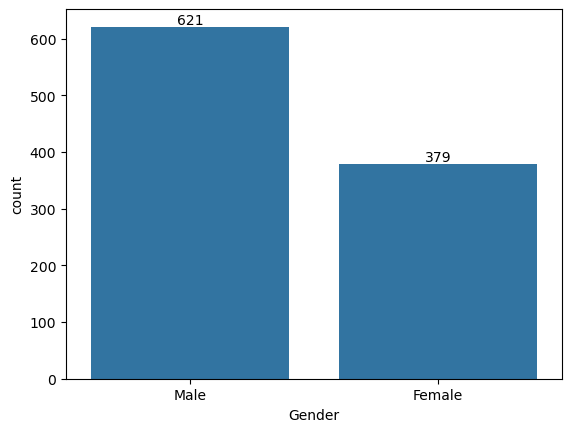

In [9]:
gender_cnt=df["Gender"].value_counts()
ax=sns.barplot(gender_cnt)
ax.bar_label(ax.containers[0])

[Text(0, 0, '722'), Text(0, 0, '278')]

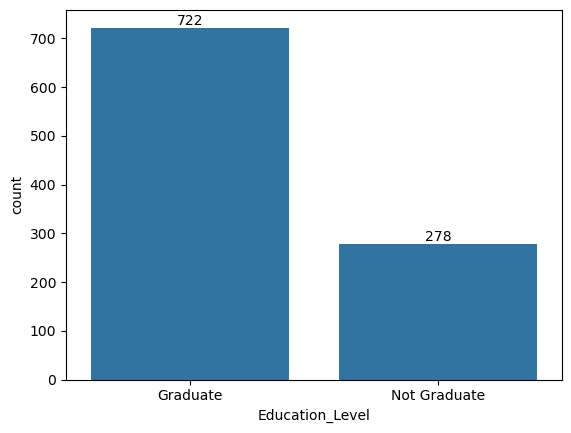

In [10]:
edu_cnt=df["Education_Level"].value_counts()
ax=sns.barplot(edu_cnt)
ax.bar_label(ax.containers[0])



<Axes: xlabel='Applicant_Income', ylabel='Count'>

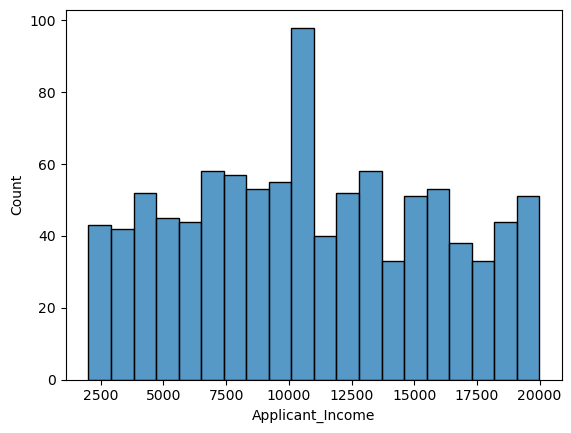

In [11]:
sns.histplot(
    data=df,
    x="Applicant_Income",
    bins=20
)

<Axes: xlabel='Coapplicant_Income', ylabel='Count'>

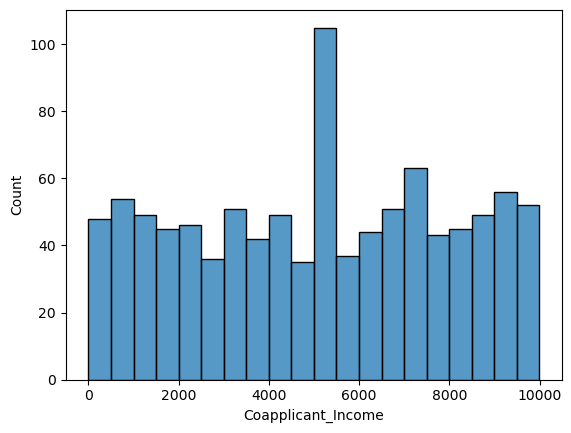

In [12]:
sns.histplot(
    data=df,
    x="Coapplicant_Income",
    bins=20
)

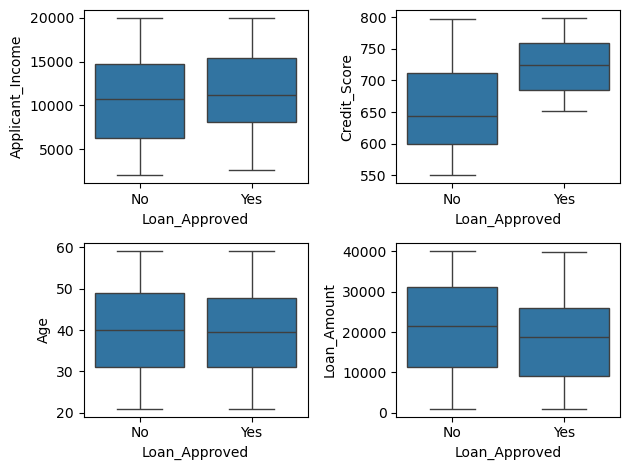

In [13]:
fig,axes=plt.subplots(2,2)
sns.boxplot(ax=axes[0,0],data=df,y="Applicant_Income",x="Loan_Approved")
sns.boxplot(ax=axes[0,1],data=df,x="Loan_Approved",y="Credit_Score")
sns.boxplot(ax=axes[1,0],data=df,x="Loan_Approved",y="Age")
sns.boxplot(ax=axes[1,1],data=df,x="Loan_Approved",y="Loan_Amount")
plt.tight_layout()

<Axes: xlabel='Credit_Score', ylabel='Count'>

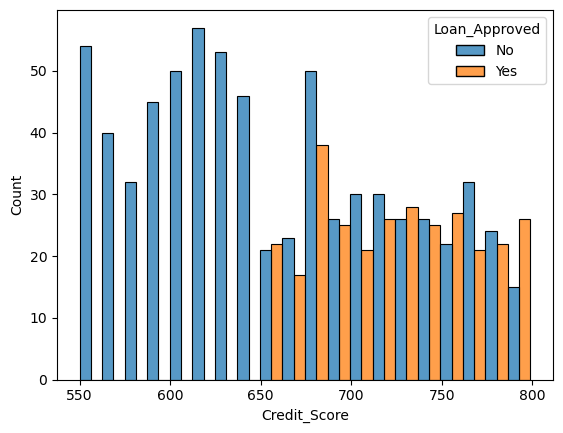

In [14]:
sns.histplot(
    data=df,
    x="Credit_Score",
    bins=20,
    hue="Loan_Approved",
    multiple="dodge"
)

<Axes: xlabel='Applicant_Income', ylabel='Count'>

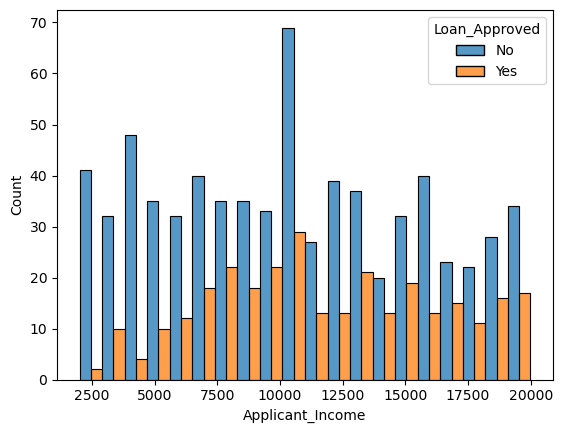

In [15]:
sns.histplot(
    data=df,
    x="Applicant_Income",
    bins=20,
    hue="Loan_Approved",
    multiple="dodge"
)

# Encoding 

In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 19 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Applicant_Income    1000 non-null   float64
 1   Coapplicant_Income  1000 non-null   float64
 2   Employment_Status   1000 non-null   object 
 3   Age                 1000 non-null   float64
 4   Marital_Status      1000 non-null   object 
 5   Dependents          1000 non-null   float64
 6   Credit_Score        1000 non-null   float64
 7   Existing_Loans      1000 non-null   float64
 8   DTI_Ratio           1000 non-null   float64
 9   Savings             1000 non-null   float64
 10  Collateral_Value    1000 non-null   float64
 11  Loan_Amount         1000 non-null   float64
 12  Loan_Term           1000 non-null   float64
 13  Loan_Purpose        1000 non-null   object 
 14  Property_Area       1000 non-null   object 
 15  Education_Level     1000 non-null   object 
 16  Gender 

In [17]:
le=LabelEncoder()
df["Education_Level"]=le.fit_transform(df["Education_Level"])
df["Loan_Approved"]=le.fit_transform(df["Loan_Approved"])

In [18]:
#Onehot encoding

cols=["Gender","Employer_Category","Property_Area","Loan_Purpose","Marital_Status","Employment_Status"]
ohe=OneHotEncoder(drop="first",sparse_output=False,handle_unknown="ignore")
encoded=ohe.fit_transform(df[cols])
encoded_df=pd.DataFrame(encoded,columns=ohe.get_feature_names_out(cols),index=df.index)
df=pd.concat([df.drop(columns=cols),encoded_df],axis=1)

In [19]:
df

,Applicant_Income,Coapplicant_Income,Age,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,...,Property_Area_Semiurban,Property_Area_Urban,Loan_Purpose_Car,Loan_Purpose_Education,Loan_Purpose_Home,Loan_Purpose_Personal,Marital_Status_Single,Employment_Status_Salaried,Employment_Status_Self-employed,Employment_Status_Unemployed
0,17795.000000,1387.0,51.0,0.0,637.0,4.0,0.53,19403.000000,45638.0,16619.0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0
1,2860.000000,2679.0,46.0,3.0,621.0,2.0,0.30,2580.000000,49272.0,38687.0,...,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
2,7390.000000,2106.0,25.0,2.0,674.0,4.0,0.20,13844.000000,6908.0,27943.0,...,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0
3,13964.000000,8173.0,40.0,2.0,579.0,3.0,0.31,9553.000000,10844.0,27819.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
4,13284.000000,4223.0,31.0,2.0,721.0,1.0,0.29,9386.000000,37629.0,12741.0,...,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,10852.571579,9092.0,58.0,0.0,557.0,0.0,0.59,5370.000000,43563.0,8311.0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0
996,3279.000000,6356.0,58.0,1.0,646.0,3.0,0.19,9940.452632,18361.0,22563.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
997,15192.000000,8433.0,48.0,1.0,666.0,1.0,0.40,8581.000000,41335.0,16203.0,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
998,9083.000000,7380.0,50.0,1.0,748.0,3.0,0.31,13491.000000,8933.0,10290.0,...,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0


# Correlation Heatmap

In [20]:
num_cols=df.select_dtypes(include="number")
num_matrix=num_cols.corr()

<Axes: >

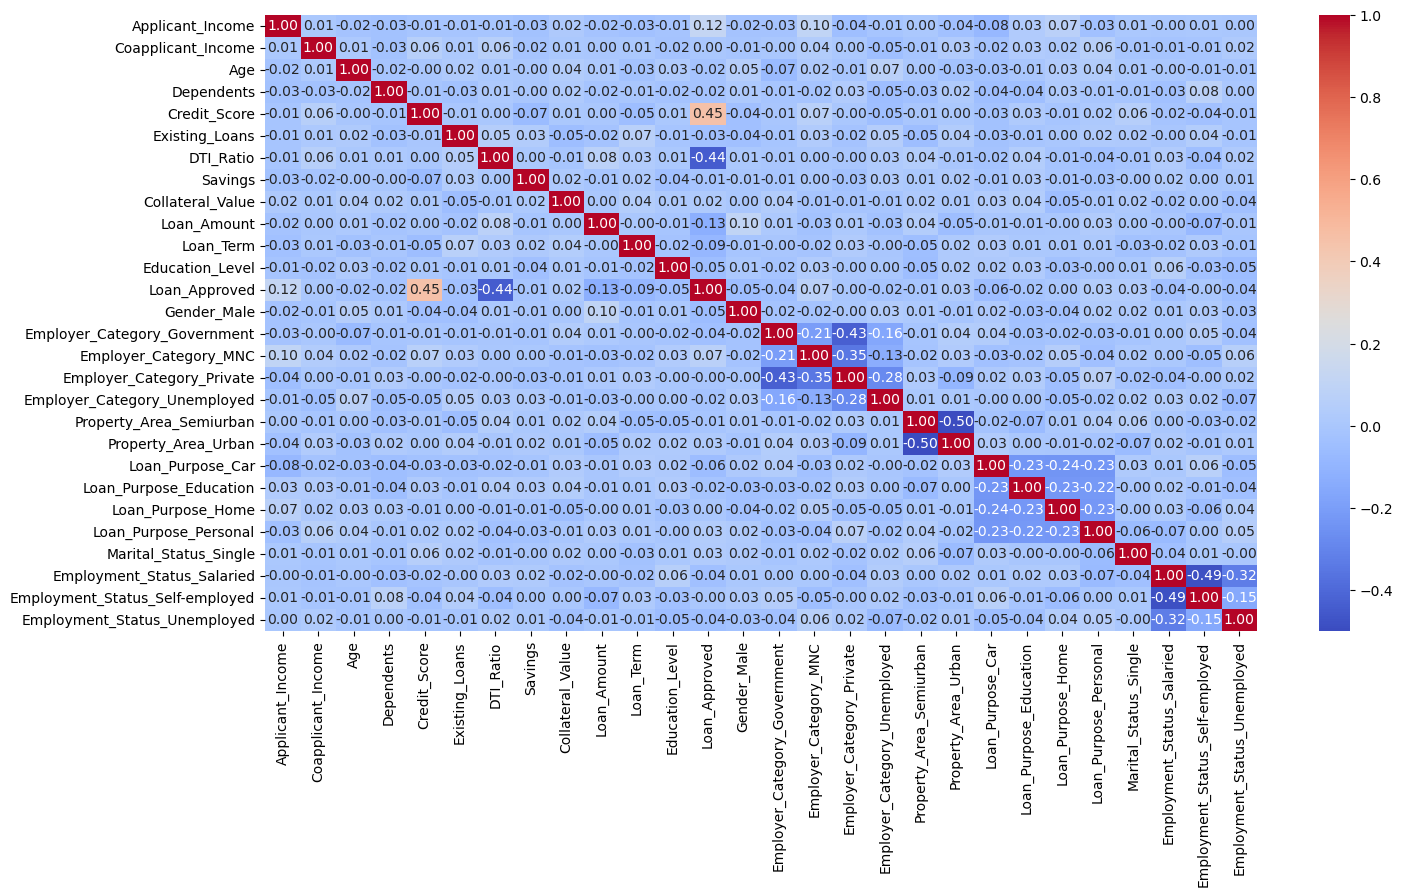

In [21]:
plt.figure(figsize=(16,8))
sns.heatmap(
    num_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

# Train-Test-Split

In [22]:
X=df.drop("Loan_Approved",axis=1)
y=df["Loan_Approved"]
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)
#scaling  the data
scaler=StandardScaler()
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)

In [23]:
X_train_scaled

array([[-1.01234556e+00,  1.02716377e+00, -8.22511453e-01, ...,
         9.65591606e-01, -4.82354268e-01, -3.12079621e-01],
       [-1.23639141e+00, -1.59187898e+00,  9.15886794e-01, ...,
         9.65591606e-01, -4.82354268e-01, -3.12079621e-01],
       [-1.15862490e-02,  1.33606578e+00, -3.65038230e-01, ...,
         9.65591606e-01, -4.82354268e-01, -3.12079621e-01],
       ...,
       [-2.27277589e-01,  3.50089621e-01, -8.22511453e-01, ...,
        -1.03563452e+00, -4.82354268e-01, -3.12079621e-01],
       [ 1.12970221e+00, -4.64700438e-01,  1.19037073e+00, ...,
        -1.03563452e+00,  2.07316503e+00, -3.12079621e-01],
       [-1.75526629e+00,  1.43417276e-02,  9.40348249e-04, ...,
        -1.03563452e+00, -4.82354268e-01,  3.20431048e+00]],
      shape=(800, 27))

# Training and Evaluating The Model

In [24]:
#Logistic Regression
log_model=LogisticRegression()
log_model.fit(X_train_scaled,y_train)
y_pred=log_model.predict(X_test_scaled)
# Eval
print("Logistic Regression Model")
print("precision_score:",precision_score(y_test,y_pred))
print("recall_score:",recall_score(y_test,y_pred))
print("accuracy_score:",accuracy_score(y_test,y_pred))
print("f1_score:",f1_score(y_test,y_pred))
print("Confusion_matrix",confusion_matrix(y_test,y_pred))


Logistic Regression Model
precision_score: 0.7833333333333333
recall_score: 0.7704918032786885
accuracy_score: 0.865
f1_score: 0.7768595041322314
Confusion_matrix [[126  13]
 [ 14  47]]


In [26]:
#KNN Classifier
knn_model=KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train_scaled,y_train)
y_pred=knn_model.predict(X_test_scaled)
# Eval
print(" KNN Model")
print("precision_score:",precision_score(y_test,y_pred))
print("recall_score:",recall_score(y_test,y_pred))
print("accuracy_score:",accuracy_score(y_test,y_pred))
print("f1_score:",f1_score(y_test,y_pred))
print("Confusion_matrix",confusion_matrix(y_test,y_pred)) 

 KNN Model
precision_score: 0.6274509803921569
recall_score: 0.5245901639344263
accuracy_score: 0.76
f1_score: 0.5714285714285714
Confusion_matrix [[120  19]
 [ 29  32]]


In [34]:
# Naive bayes

gnb_model=GaussianNB()
gnb_model.fit(X_train_scaled,y_train)
y_pred=gnb_model.predict(X_test_scaled)
# Eval
print("precision_score:",precision_score(y_test,y_pred))
print("recall_score:",recall_score(y_test,y_pred))
print("accuracy_score:",accuracy_score(y_test,y_pred))
print("f1_score:",f1_score(y_test,y_pred))
print("Confusion_matrix",confusion_matrix(y_test,y_pred))

precision_score: 0.7833333333333333
recall_score: 0.7704918032786885
accuracy_score: 0.865
f1_score: 0.7768595041322314
Confusion_matrix [[126  13]
 [ 14  47]]


# Feature Engineering

In [30]:
#adding and transform features
df["Credit_Score_sq"]=df["Credit_Score"]**2
df["DTI_Ratio_sq"]=df["DTI_Ratio"]**2
X=df.drop(columns=["DTI_Ratio","Credit_Score","Loan_Approved"])
y=df["Loan_Approved"]
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)
#scaling  the data
scaler=StandardScaler()
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)

In [31]:
#KNN Classifier
knn_model=KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train_scaled,y_train)
y_pred=knn_model.predict(X_test_scaled)
# Eval
print(" KNN Model")
print("precision_score:",precision_score(y_test,y_pred))
print("recall_score:",recall_score(y_test,y_pred))
print("accuracy_score:",accuracy_score(y_test,y_pred))
print("f1_score:",f1_score(y_test,y_pred))
print("Confusion_matrix",confusion_matrix(y_test,y_pred)) 

 KNN Model
precision_score: 0.62
recall_score: 0.5081967213114754
accuracy_score: 0.755
f1_score: 0.5585585585585585
Confusion_matrix [[120  19]
 [ 30  31]]


In [32]:
#Logistic Regression
log_model=LogisticRegression()
log_model.fit(X_train_scaled,y_train)
y_pred=log_model.predict(X_test_scaled)
# Eval
print("Logistic Regression Model")
print("precision_score:",precision_score(y_test,y_pred))
print("recall_score:",recall_score(y_test,y_pred))
print("accuracy_score:",accuracy_score(y_test,y_pred))
print("f1_score:",f1_score(y_test,y_pred))
print("Confusion_matrix",confusion_matrix(y_test,y_pred))


Logistic Regression Model
precision_score: 0.7903225806451613
recall_score: 0.8032786885245902
accuracy_score: 0.875
f1_score: 0.7967479674796748
Confusion_matrix [[126  13]
 [ 12  49]]


In [25]:
# Naive bayes

gnb_model=GaussianNB()
gnb_model.fit(X_train_scaled,y_train)
y_pred=gnb_model.predict(X_test_scaled)
# Eval
print("precision_score:",precision_score(y_test,y_pred))
print("recall_score:",recall_score(y_test,y_pred))
print("accuracy_score:",accuracy_score(y_test,y_pred))
print("f1_score:",f1_score(y_test,y_pred))
print("Confusion_matrix",confusion_matrix(y_test,y_pred))


precision_score: 0.8035714285714286
recall_score: 0.7377049180327869
accuracy_score: 0.865
f1_score: 0.7692307692307693
Confusion_matrix [[128  11]
 [ 16  45]]
